In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

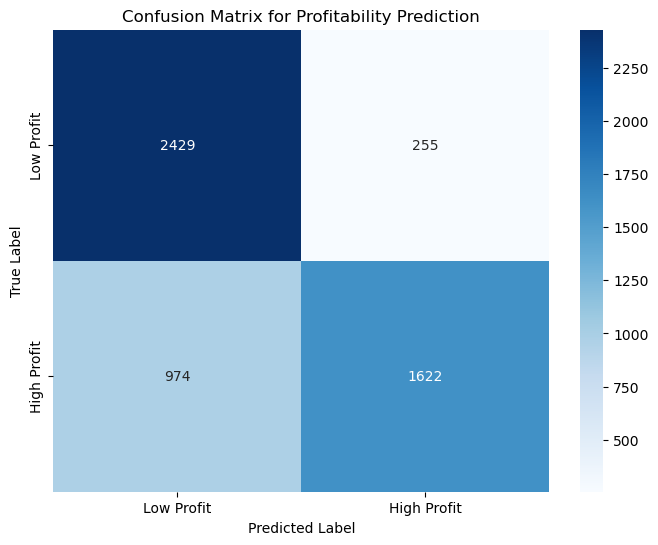

Accuracy: 76.72%


In [15]:
sales = pd.read_csv('Cleaned_FactSale.csv')
customer = pd.read_csv('Cleaned_DimCustomer.csv')
stock = pd.read_csv('Cleaned_StockItem.csv')

df = sales.merge(stock, on='Stock Item Key', how='left')
df = df.merge(customer, on='Customer Key', how='left')

df.columns = df.columns.str.strip()
features = ['Quantity', 'Unit Price_x', 'Recommended Retail Price', 'Credit Limit']
X = df[features].fillna(0)

median_profit = df['Profit'].median()
y = (df['Profit'] > median_profit).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred_continuous = model.predict(X_test)
y_pred_class = (y_pred_continuous > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Profit', 'High Profit'], 
            yticklabels=['Low Profit', 'High Profit'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Profitability Prediction')
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred_class) * 100:.2f}%")